In [24]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


In [25]:
# ---------------------------
# 1) SETUP AND SEED
# ---------------------------
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [26]:
# ---------------------------
# 2) LOAD ORIGINAL DATA
# ---------------------------
original_data = pd.read_csv("../../../data/resample_minmax_all.csv")

# Keep a copy of apogee_id
apogee_ids = original_data["apogee_id"].copy()

# Keep the 17 abundance columns, dropping ID and any extra columns
columns_to_drop = ["apogee_id", "TEFF", "J", "H", "K", "LOGG"]
abundance_data = original_data.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)

col_names = [
    "C_FE", "CI_FE", "N_FE", "O_FE", "NA_FE", "MG_FE", "AL_FE",
    "SI_FE", "S_FE", "K_FE", "CA_FE", "TI_FE", "V_FE", "CR_FE",
    "MN_FE", "NI_FE", "FE_H"
]

print("Original abundance data shape:", abundance_data.shape)

Original abundance data shape: (175770, 17)


In [27]:
# ---------------------------
# 3) DEFINE DATASET & MODEL
# ---------------------------
class InverseProjectionDataset(Dataset):
    def __init__(self, x_latent, y_17):
        self.x_latent = torch.tensor(x_latent, dtype=torch.float32)
        self.y_17 = torch.tensor(y_17, dtype=torch.float32)
        self.n = self.x_latent.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x_latent[idx], self.y_17[idx]

class InverseProjectionNet(nn.Module):
    """
    A feed-forward network to reconstruct 17D abundances from an N-D embedding.
    Architecture: N -> 64 -> 32 -> 17, with BatchNorm and LeakyReLU.
    """
    def __init__(self, input_dim=2, output_dim=17):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        return self.fc3(x)


In [28]:
# ---------------------------
# Define Global Train/Test Split (consistent across all methods)
# ---------------------------
global_indices = np.arange(len(abundance_data))
np.random.shuffle(global_indices)
split_ratio = 0.9
split_point = int(split_ratio * len(abundance_data))
global_train_idx = set(global_indices[:split_point])
global_test_idx = set(global_indices[split_point:])

print(f"Global train size: {len(global_train_idx)}, Global test size: {len(global_test_idx)}")


Global train size: 158193, Global test size: 17577


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_and_evaluate(latent_df, abundance_df, apogee_ids, method_name, input_dim, global_train_idx, global_test_idx):
    """
    Trains a reconstructor for a given latent_df (with 'apogee_id' + latent dims),
    merging it with the original data to ensure consistent ordering,
    then splits into train/test using the global indices.
    The model is trained on GPU if available.
    """
    # Merge on apogee_id to ensure consistent ordering with the original dataset
    merged = pd.merge(
        latent_df,
        pd.DataFrame({"apogee_id": apogee_ids, "index_orig": np.arange(len(apogee_ids))}),
        on="apogee_id",
        how="inner"
    ).sort_values("index_orig")

    if len(merged) != len(abundance_df):
        print(f"Warning: {method_name} has {len(merged)} rows; original data has {len(abundance_df)}.")

    abundance_ordered = abundance_df.iloc[merged["index_orig"].values]
    latent_cols = [c for c in merged.columns if c not in ["apogee_id", "index_orig"]]
    X_latent = merged[latent_cols].values.astype(np.float32)
    Y_abund = abundance_ordered.values.astype(np.float32)

    mask_train = merged["index_orig"].isin(global_train_idx).values
    mask_test  = merged["index_orig"].isin(global_test_idx).values

    X_train = X_latent[mask_train]
    X_test  = X_latent[mask_test]
    Y_train = Y_abund[mask_train]
    Y_test  = Y_abund[mask_test]

    train_dataset = InverseProjectionDataset(X_train, Y_train)
    test_dataset = InverseProjectionDataset(X_test, Y_test)
    train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False)

    # Build and train the model, and move it to the chosen device.
    model = InverseProjectionNet(input_dim=input_dim, output_dim=17).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    patience = 10
    best_val_loss = float("inf")
    epochs_no_improve = 0
    n_epochs = 100

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item()
        val_loss = running_val_loss / len(test_loader)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"[{method_name}] Epoch {epoch + 1}/{n_epochs}, Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        if val_loss < best_val_loss - 1e-7:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{method_name}] Early stopping triggered at epoch {epoch + 1}")
                break

    model.load_state_dict(best_model_state)
    print(f"[{method_name}] Training complete. Best Val Loss: {best_val_loss}")

    model_save_path = f"output_weight/reconstructor_{method_name}.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"[{method_name}] Model saved to {model_save_path}")

    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_true.append(y_batch.cpu().numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    mse_global = np.mean((all_preds - all_true)**2)
    cov_matrix = np.cov(all_true, rowvar=False)
    total_variance = np.trace(cov_matrix)
    explained_variance = 1 - (mse_global / total_variance)

    return {
        "model": model,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "X_test": X_test,
        "Y_test": Y_test,
        "all_preds": all_preds,
        "all_true": all_true,
        "mse_global": mse_global,
        "explained_variance": explained_variance,
        "test_idx": merged["index_orig"].values[mask_test],
        "merged_df": merged
    }


Using device: cuda


In [30]:
projection_files = [
    "PCA_latent_space_2D.csv",
    "PCA_latent_space_3D.csv",
    "PCA_latent_space_4D.csv",
    "CosineKPCA_latent_space_2D.csv",
    "CosineKPCA_latent_space_3D.csv",
    "CosineKPCA_latent_space_4D.csv"
    #"autoencoder_latent_space_2D.csv",
    #"autoencoder_latent_space_3D.csv",
    #"autoencoder_latent_space_4D.csv",
    #"tsne_embedding_2D.csv",
    #"umap_embedding_2D.csv",
    #"umap_embedding_3D.csv",
    #"umap_embedding_4D.csv",
    #"VAE_latent_space_2D.csv",
    #"VAE_latent_space_3D.csv",
    #"VAE_latent_space_4D.csv",
    #"siamese_multitask_embedding_2D.csv",
    #"siamese_multitask_embedding_3D.csv",
    #"siamese_multitask_embedding_4D.csv"
]

In [31]:
# ---------------------------
# 5) LOOP OVER PROJECTION FILES --- SHOULD ONLY BE RUN FOR TRAINING --- if only use comparison can only fun following blocks
# ---------------------------

results = {}

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    method_path = os.path.join("output_dataset", proj_file)
    df_latent = pd.read_csv(method_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    latent_cols = [c for c in df_latent.columns if c != "apogee_id"]
    input_dim = len(latent_cols)

    print(f"\n=== Training reconstructor for {method_name} (dim={input_dim}) ===")
    out = train_and_evaluate(
        latent_df=df_latent,
        abundance_df=abundance_data,
        apogee_ids=original_data["apogee_id"],
        method_name=method_name,
        input_dim=input_dim,
        global_train_idx=global_train_idx,
        global_test_idx=global_test_idx
    )
    results[method_name] = out



=== Training reconstructor for PCA_latent_space_2D (dim=2) ===
[PCA_latent_space_2D] Epoch 10/100, Train Loss = 0.008397, Val Loss = 0.007346
[PCA_latent_space_2D] Epoch 20/100, Train Loss = 0.003146, Val Loss = 0.003086
[PCA_latent_space_2D] Epoch 30/100, Train Loss = 0.002332, Val Loss = 0.002296
[PCA_latent_space_2D] Epoch 40/100, Train Loss = 0.001966, Val Loss = 0.001960
[PCA_latent_space_2D] Epoch 50/100, Train Loss = 0.001789, Val Loss = 0.001794
[PCA_latent_space_2D] Epoch 60/100, Train Loss = 0.001714, Val Loss = 0.001712
[PCA_latent_space_2D] Epoch 70/100, Train Loss = 0.001657, Val Loss = 0.001664
[PCA_latent_space_2D] Epoch 80/100, Train Loss = 0.001631, Val Loss = 0.001635
[PCA_latent_space_2D] Epoch 90/100, Train Loss = 0.001614, Val Loss = 0.001622
[PCA_latent_space_2D] Epoch 100/100, Train Loss = 0.001605, Val Loss = 0.001618
[PCA_latent_space_2D] Training complete. Best Val Loss: 0.0016118148976767604
[PCA_latent_space_2D] Model saved to output_weight/reconstructor_PC

In [32]:
# ---------------------------
# 7) PICK THE SAME STAR (BY apogee_id) FROM THE TEST SET AND COMPARE RECONSTRUCTIONS
# ---------------------------

print("Original abundance data shape:", abundance_data.shape)

test_indices_sorted = sorted(list(global_test_idx))
test_original_df = original_data.loc[test_indices_sorted, ["apogee_id"] + col_names].reset_index(drop=True)
test_original_df.to_csv("reconstructed_csv/test_original_minmax_all_sorted_indices.csv", index=False)
print("Saved file to 'reconstructed_csv/test_original_sorted_indices.csv'")

# Save the original train dataset
train_original_df = original_data.loc[list(global_train_idx), ["apogee_id"] + col_names].reset_index(drop=True)
train_original_df.to_csv("reconstructed_csv/train_original_minmax_all_sorted_indices.csv", index=False)
print("Saved file to 'reconstructed_csv/train_original_sorted_indices.csv'")



Original abundance data shape: (175770, 17)
Saved file to 'reconstructed_csv/test_original_sorted_indices.csv'
Saved file to 'reconstructed_csv/train_original_sorted_indices.csv'


In [33]:
class InverseProjectionInferenceDataset(Dataset):
    """
    Redifinition used for re construction.
    """
    def __init__(self, x_latent):
        self.x_latent = torch.tensor(x_latent, dtype=torch.float32)
        self.n = self.x_latent.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x_latent[idx]

In [34]:
os.makedirs("reconstructed_csv", exist_ok=True)

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    latent_path = os.path.join("output_dataset", proj_file)
    weights_path = os.path.join("output_weight", f"reconstructor_{method_name}.pth")


    if not os.path.isfile(latent_path):
        print(f"[{method_name}] Fichier latent introuvable: {latent_path}. Skip.")
        continue
    if not os.path.isfile(weights_path):
        print(f"[{method_name}] Fichier de poids introuvable: {weights_path}. Skip.")
        continue

    print(f"\n=== Reconstruction du test set pour {method_name} ===")

    df_latent = pd.read_csv(latent_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    temp_index_df = pd.DataFrame({"apogee_id": apogee_ids, "index_orig": np.arange(len(apogee_ids))})
    merged = pd.merge(
        df_latent,
        temp_index_df,
        on="apogee_id",
        how="inner"
    ).sort_values("index_orig")

    mask_test = merged["index_orig"].isin(global_test_idx).values
    merged_test = merged.loc[mask_test].copy()
    merged_test_sorted = merged_test.sort_values("index_orig")  # pour ordre croissant
    latent_cols = [c for c in merged_test_sorted.columns if c not in ["apogee_id", "index_orig"]]

    X_test = merged_test_sorted[latent_cols].values.astype(np.float32)

    input_dim = len(latent_cols)
    model = InverseProjectionNet(input_dim=input_dim, output_dim=17).to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    test_dataset = InverseProjectionInferenceDataset(X_test)
    test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            all_preds.append(preds.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)


    recon_df = pd.DataFrame(all_preds, columns=col_names)
    recon_df.insert(0, "apogee_id", merged_test_sorted["apogee_id"].values)
    recon_df.insert(1, "index_orig", merged_test_sorted["index_orig"].values)

    output_csv_path = os.path.join("reconstructed_csv", f"test_reconstructed_{method_name}.csv")
    recon_df.to_csv(output_csv_path, index=False)
    print(f"[{method_name}] Données reconstruites du test set sauvegardées dans: {output_csv_path}")

print("\nTerminé ! Vous avez maintenant un 'test_original.csv' et, pour chaque méthode, un 'test_reconstructed_<method>.csv' dans le dossier 'reconstructed_csv'.")


=== Reconstruction du test set pour PCA_latent_space_2D ===
[PCA_latent_space_2D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_PCA_latent_space_2D.csv

=== Reconstruction du test set pour PCA_latent_space_3D ===
[PCA_latent_space_3D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_PCA_latent_space_3D.csv

=== Reconstruction du test set pour PCA_latent_space_4D ===
[PCA_latent_space_4D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_PCA_latent_space_4D.csv

=== Reconstruction du test set pour CosineKPCA_latent_space_2D ===
[CosineKPCA_latent_space_2D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_CosineKPCA_latent_space_2D.csv

=== Reconstruction du test set pour CosineKPCA_latent_space_3D ===
[CosineKPCA_latent_space_3D] Données reconstruites du test set sauvegardées dans: reconstructed_csv/test_reconstructed_Cosi


Comparing reconstructions for apogee_id=2M00000943+6254542 (row_index_orig=5)


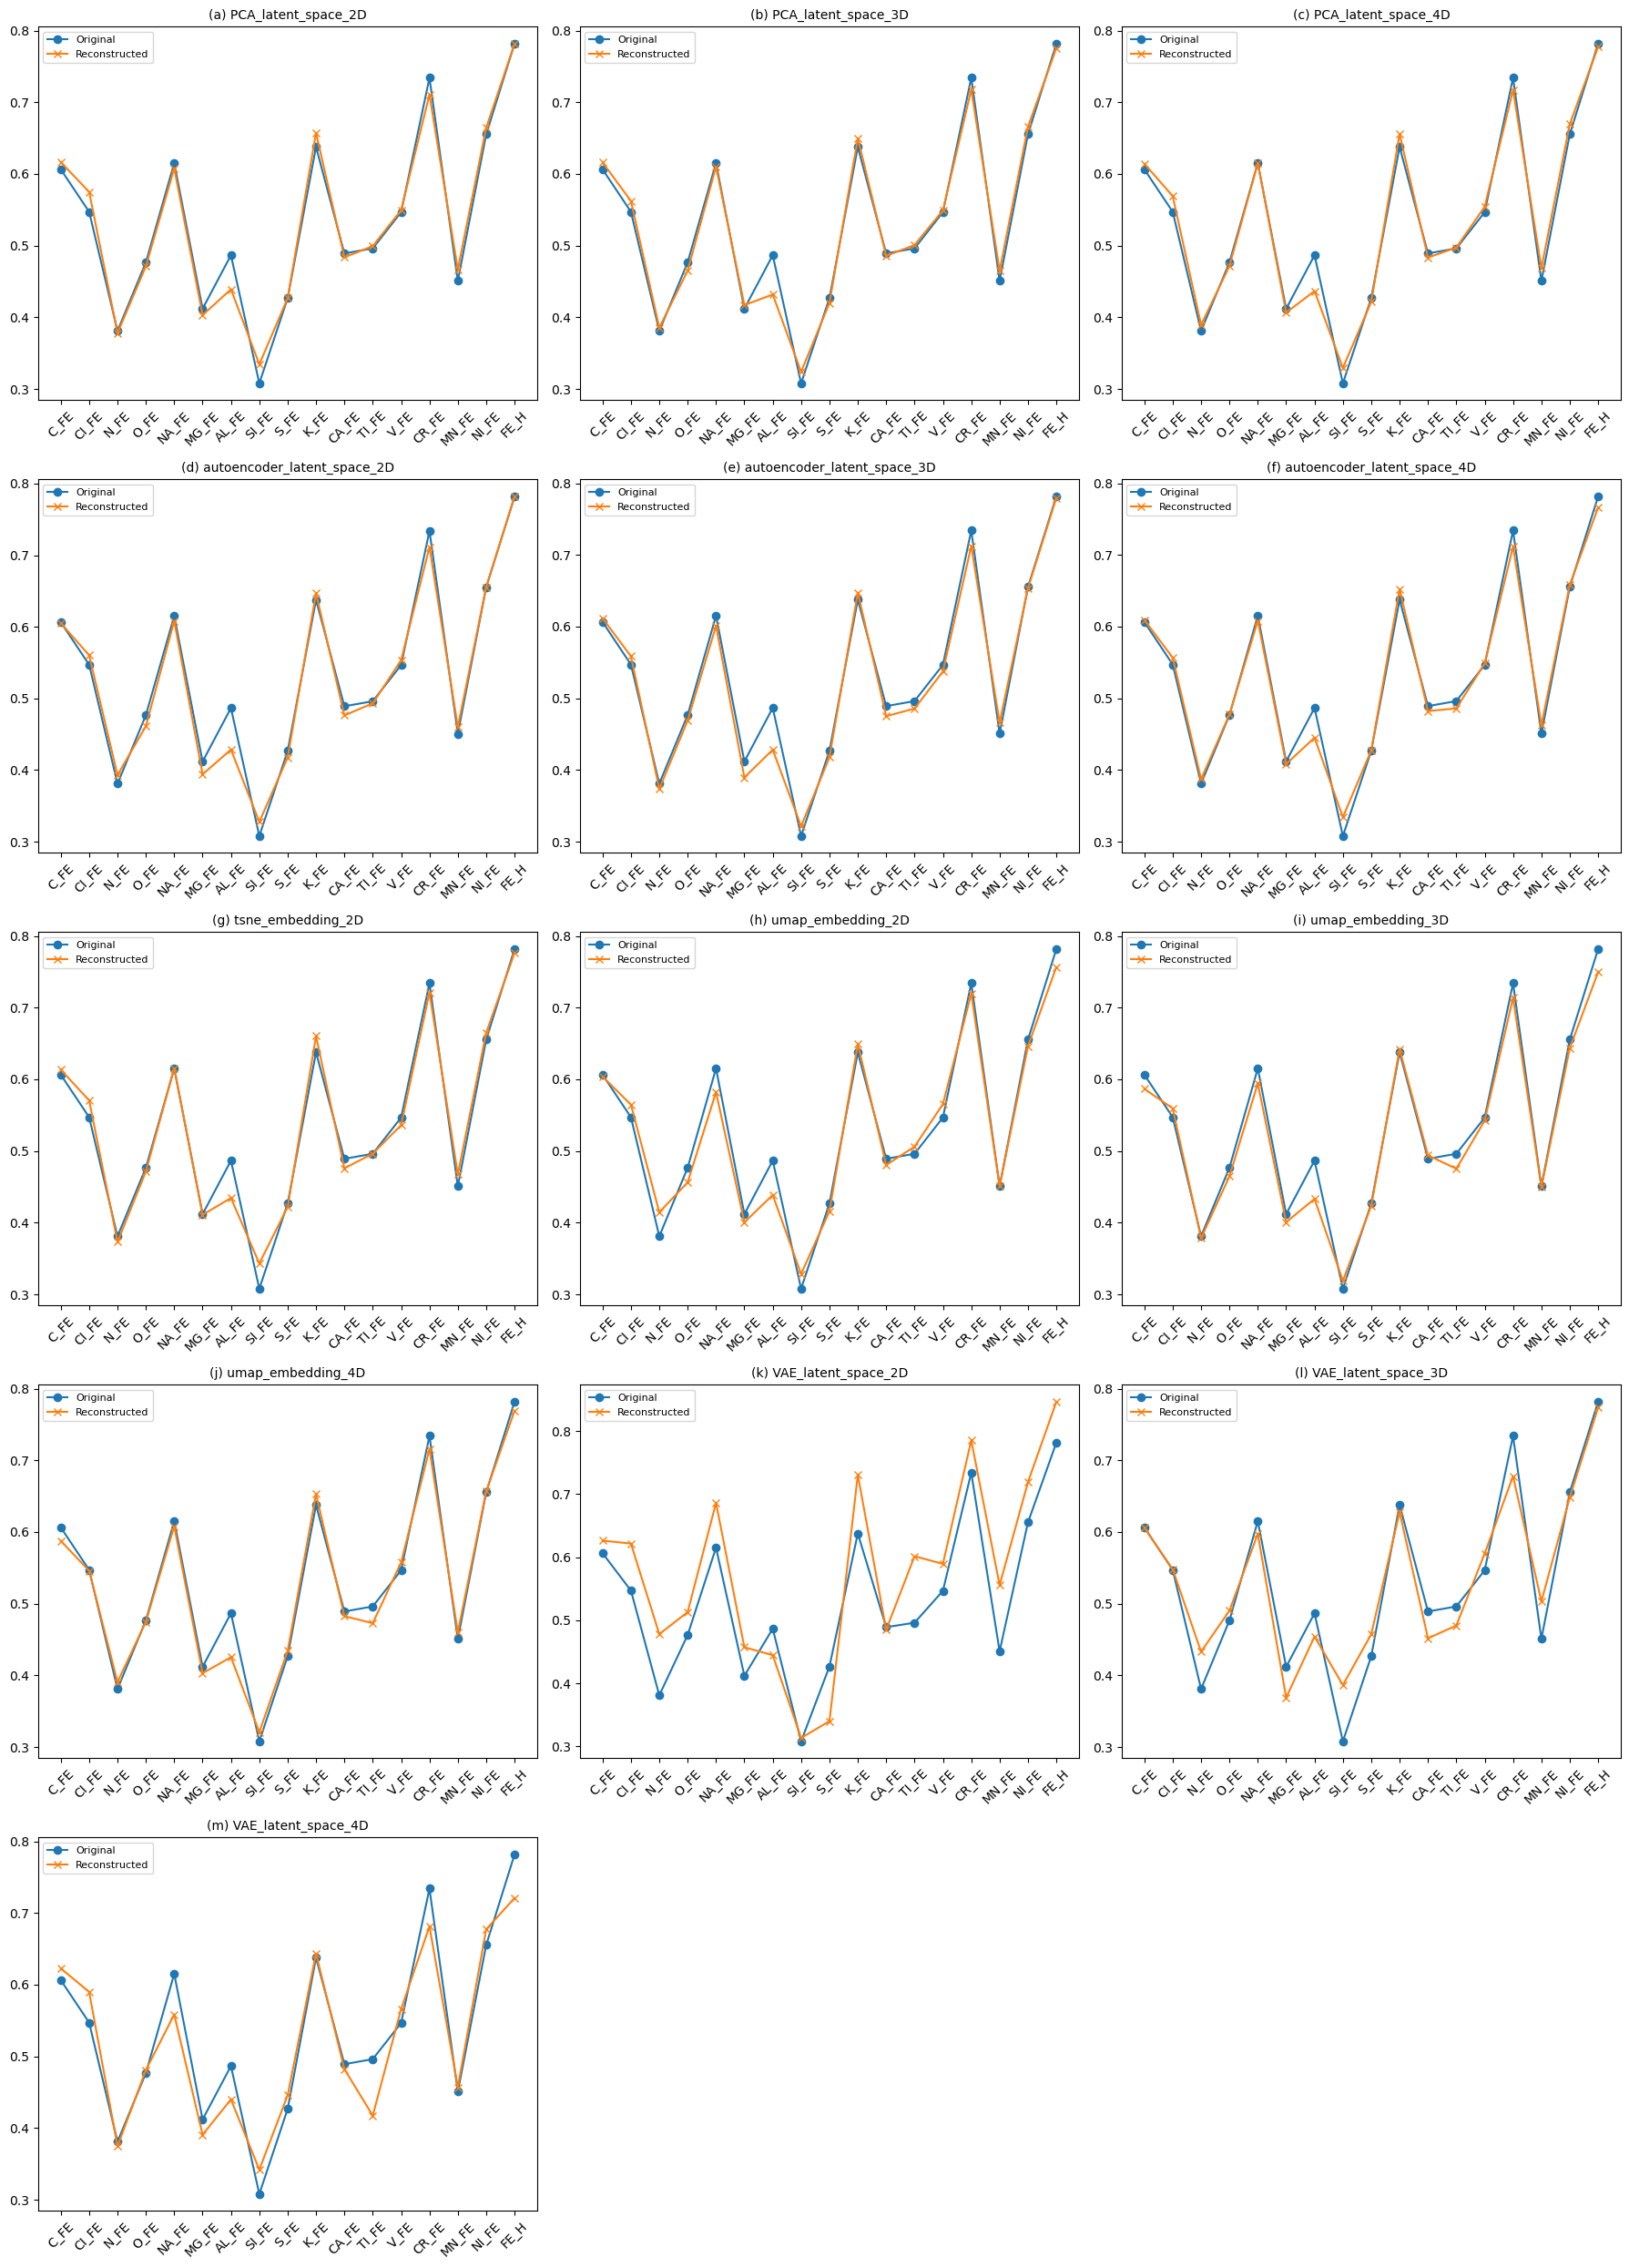

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 7) PICK THE SAME STAR FROM THE TEST SET (CONSISTENT SPLIT) AND PLOT ALL METHODS
# ---------------------------
# 1) Select the first method's test set to guarantee the star is in the test set of at least one method
method_names = list(results.keys())
first_method = method_names[0]

first_method_test_idx = results[first_method]["test_idx"]
row_index_orig = first_method_test_idx[0]  # e.g. pick the first test sample
chosen_id = original_data["apogee_id"].iloc[row_index_orig]
print(f"\nComparing reconstructions for apogee_id={chosen_id} (row_index_orig={row_index_orig})")

# 2) Get the original abundance for this star
original_abundance = abundance_data.iloc[row_index_orig].values

# 3) Prepare a grid of subplots, one per method
n_methods = len(method_names)
ncols = 3  # e.g. 3 columns
nrows = (n_methods + ncols - 1) // ncols  # enough rows to fit all methods
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5*nrows))
axes = axes.flatten()

# (Optional) labels for subplots: (a), (b), (c), ...
letters = "abcdefghijklmnopqrstuvwxyz"

# 4) For each method, plot "Original vs. Reconstruction" in its own subplot
for idx, m_name in enumerate(method_names):
    ax = axes[idx]

    # Retrieve the merged_df to find index_orig
    merged_df = results[m_name]["merged_df"]
    match = merged_df[merged_df["index_orig"] == row_index_orig]
    if match.empty:
        # Star not found in this method's dataset (e.g. if some rows got dropped)
        ax.text(0.5, 0.5, f"{m_name}\nNot found", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Check if the star is in the test set for this method
    test_idx_for_method = results[m_name]["test_idx"]
    idx_pos = np.where(test_idx_for_method == row_index_orig)[0]
    if len(idx_pos) == 0:
        # The star ended up in the train set for this method
        ax.text(0.5, 0.5, f"{m_name}\nIn train set", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Retrieve the reconstruction from all_preds
    pos_in_test = idx_pos[0]
    recon = results[m_name]["all_preds"][pos_in_test]

    # Plot the original abundance (blue line) vs. reconstruction (orange line)
    ax.plot(range(len(col_names)), original_abundance, marker='o', label="Original")
    ax.plot(range(len(col_names)), recon, marker='x', label="Reconstructed")

    # Cosmetic adjustments
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45)
    subplot_label = f"({letters[idx]})" if idx < len(letters) else ""
    ax.set_title(f"{subplot_label} {m_name}", fontsize=10)
    ax.legend(fontsize=8)

# Hide any extra subplots if we have more subplot slots than methods
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [52]:
import numpy as np
import torch
from torch.utils.data import DataLoader

def compute_train_mse_for_method(m_name, results_dict, abundance_df, global_train_idx):
    """
    Rebuild the train dataset for method m_name, run inference,
    and compute the MSE on the training set.
    """
    # 1) Extract the model
    model = results_dict[m_name]["model"]
    model.eval()  # inference mode

    # 2) Extract the merged_df to see how latent data lines up with original indices
    merged_df = results_dict[m_name]["merged_df"]

    # 3) Determine which rows are in the train set for this method
    mask_train = merged_df["index_orig"].isin(global_train_idx).values

    # 4) Extract the latent columns
    latent_cols = [c for c in merged_df.columns if c not in ["apogee_id", "index_orig"]]
    X_latent = merged_df[latent_cols].values.astype(np.float32)

    # 5) Align abundance data in the same order, then slice for train
    Y_abund = abundance_df.iloc[merged_df["index_orig"].values].values.astype(np.float32)

    X_train = X_latent[mask_train]
    Y_train = Y_abund[mask_train]

    # 6) Create the train dataset and loader
    train_dataset = InverseProjectionDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=False)

    # 7) Run inference on the train set
    all_preds = []
    all_true = []
    with torch.no_grad():
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_true.append(y_batch.numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # 8) Compute the MSE
    mse_train = np.mean((all_preds - all_true)**2)
    return mse_train

# loop over each method and compute train MSE

for m_name in results.keys():
    mse_train = compute_train_mse_for_method(m_name, results, abundance_data, global_train_idx)
    print(f"{m_name} - Train MSE: {mse_train:.6f}")


PCA_latent_space_2D - Train MSE: 0.001581
PCA_latent_space_3D - Train MSE: 0.001205
PCA_latent_space_4D - Train MSE: 0.000957
autoencoder_latent_space_2D - Train MSE: 0.001273
autoencoder_latent_space_3D - Train MSE: 0.001004
autoencoder_latent_space_4D - Train MSE: 0.000801
tsne_embedding_2D - Train MSE: 0.001537
umap_embedding_2D - Train MSE: 0.001601
umap_embedding_3D - Train MSE: 0.001419
umap_embedding_4D - Train MSE: 0.001801
VAE_latent_space_2D - Train MSE: 0.006970
VAE_latent_space_3D - Train MSE: 0.003320
VAE_latent_space_4D - Train MSE: 0.002608


/tmp/ipykernel_85256/160567660.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dist_data, labels=labels, vert=True)


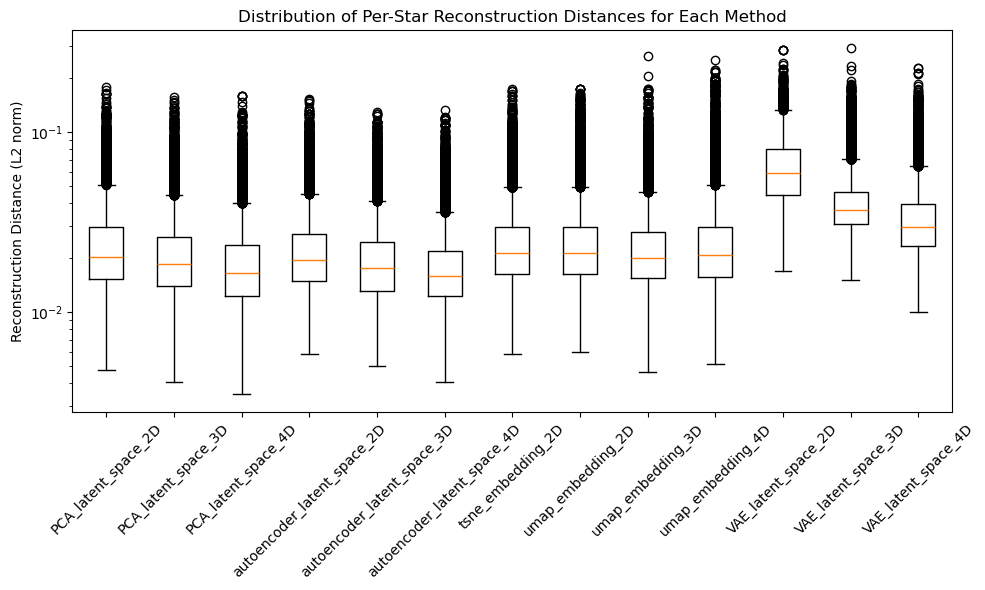

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store per-star errors (distances) for each method
method_starwise_distances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # Compute the L2 distance for each star: sqrt( sum( (pred - true)^2 ) )
    #starwise_dist = np.sqrt(np.sum((all_preds - all_true)**2, axis=1))  # shape [N_test]
    starwise_dist = np.mean(np.abs(all_preds - all_true), axis=1)


    method_starwise_distances[m_name] = starwise_dist

# Boxplot comparing per-star distances across all methods
plt.figure(figsize=(10, 6))
labels = list(method_starwise_distances.keys())
dist_data = [method_starwise_distances[m] for m in labels]
plt.boxplot(dist_data, labels=labels, vert=True)
plt.xticks(rotation=45)
plt.semilogy()
plt.ylabel("Reconstruction Distance (L2 norm)")
plt.title("Distribution of Per-Star Reconstruction Distances for Each Method")
plt.tight_layout()
plt.show()


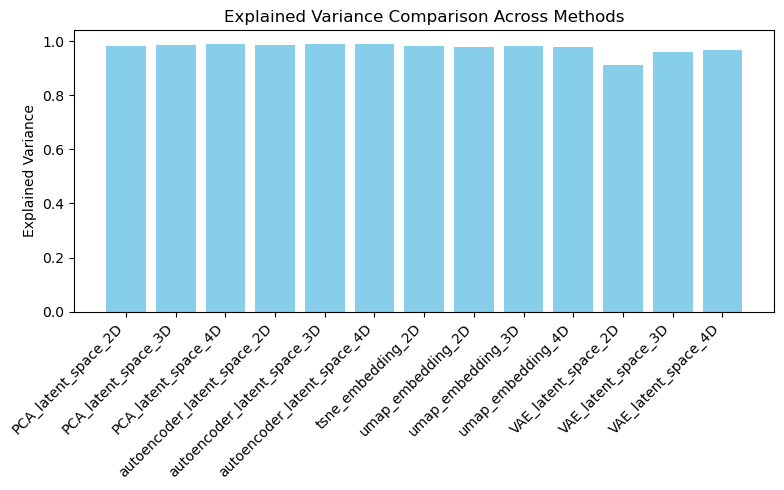

In [58]:
method_explained_variances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # If it's already in the dictionary:
    if "explained_variance" in data_dict:
        ev = data_dict["explained_variance"]
    else:
        # Calculate it if not stored
        cov_matrix = np.cov(all_true, rowvar=False)
        total_variance = np.trace(cov_matrix)
        mse_global = np.mean((all_preds - all_true)**2)
        explained_variance = 1 - (mse_global / total_variance)

    method_explained_variances[m_name] = ev

# Plot a bar chart of explained variance for each method
plt.figure(figsize=(8, 5))
labels = list(method_explained_variances.keys())
ev_values = [method_explained_variances[m] for m in labels]
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.semilogy()
plt.title("Explained Variance Comparison Across Methods")
plt.tight_layout()
plt.show()


In [7]:
# ---------------------------
# 5) LOOP OVER PROJECTION FILES
# ---------------------------
# Example: you might have these files:
projection_files = [
    "siamese_multitask_embedding_2D.csv",
     "siamese_multitask_embedding_3D.csv",
     "siamese_multitask_embedding_4D.csv"
]
results = {}

for proj_file in projection_files:
    method_name = os.path.splitext(proj_file)[0]
    method_path = os.path.join("output_dataset", proj_file)
    df_latent = pd.read_csv(method_path)
    if "apogee_id" not in df_latent.columns:
        print(f"Skipping {proj_file}: 'apogee_id' not found.")
        continue

    latent_cols = [c for c in df_latent.columns if c != "apogee_id"]
    input_dim = len(latent_cols)

    print(f"\n=== Training reconstructor for {method_name} (dim={input_dim}) ===")
    out = train_and_evaluate(
        latent_df=df_latent,
        abundance_df=abundance_data,
        apogee_ids=original_data["apogee_id"],
        method_name=method_name,
        input_dim=input_dim,
        global_train_idx=global_train_idx,
        global_test_idx=global_test_idx
    )
    results[method_name] = out



=== Training reconstructor for siamese_multitask_embedding_2D (dim=2) ===
[siamese_multitask_embedding_2D] Epoch 10/100, Train Loss = 0.009672, Val Loss = 0.008699
[siamese_multitask_embedding_2D] Epoch 20/100, Train Loss = 0.005074, Val Loss = 0.005027
[siamese_multitask_embedding_2D] Epoch 30/100, Train Loss = 0.004173, Val Loss = 0.004141
[siamese_multitask_embedding_2D] Epoch 40/100, Train Loss = 0.003665, Val Loss = 0.003645
[siamese_multitask_embedding_2D] Epoch 50/100, Train Loss = 0.003437, Val Loss = 0.003432
[siamese_multitask_embedding_2D] Epoch 60/100, Train Loss = 0.003323, Val Loss = 0.003321
[siamese_multitask_embedding_2D] Epoch 70/100, Train Loss = 0.003239, Val Loss = 0.003240
[siamese_multitask_embedding_2D] Epoch 80/100, Train Loss = 0.003190, Val Loss = 0.003191
[siamese_multitask_embedding_2D] Epoch 90/100, Train Loss = 0.003157, Val Loss = 0.003158
[siamese_multitask_embedding_2D] Epoch 100/100, Train Loss = 0.003130, Val Loss = 0.003133
[siamese_multitask_embed


Comparing reconstructions for apogee_id=2M00000943+6254542 (row_index_orig=5)


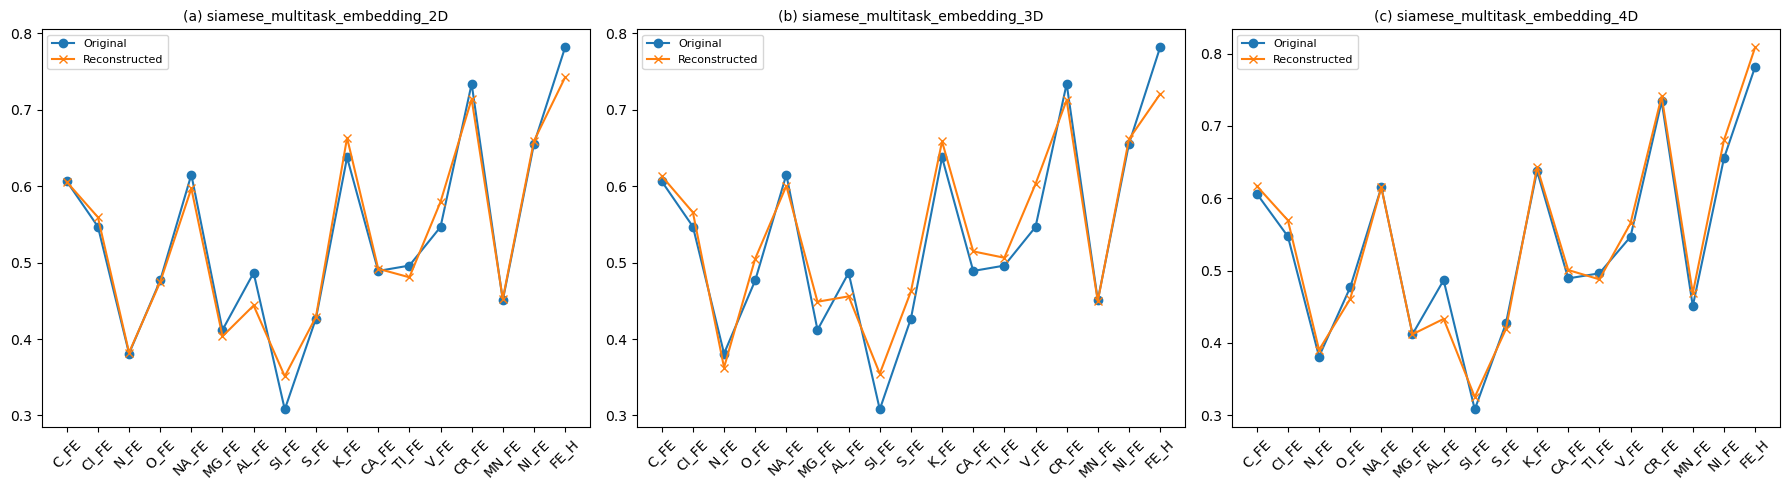

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 7) PICK THE SAME STAR FROM THE TEST SET (CONSISTENT SPLIT) AND PLOT ALL METHODS
# ---------------------------
# 1) Select the first method's test set to guarantee the star is in the test set of at least one method
method_names = list(results.keys())
first_method = method_names[0]

first_method_test_idx = results[first_method]["test_idx"]
row_index_orig = first_method_test_idx[0]  # e.g. pick the first test sample
chosen_id = original_data["apogee_id"].iloc[row_index_orig]
print(f"\nComparing reconstructions for apogee_id={chosen_id} (row_index_orig={row_index_orig})")

# 2) Get the original abundance for this star
original_abundance = abundance_data.iloc[row_index_orig].values

# 3) Prepare a grid of subplots, one per method
n_methods = len(method_names)
ncols = 3  # e.g. 3 columns
nrows = (n_methods + ncols - 1) // ncols  # enough rows to fit all methods
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5*nrows))
axes = axes.flatten()

# (Optional) labels for subplots: (a), (b), (c), ...
letters = "abcdefghijklmnopqrstuvwxyz"

# 4) For each method, plot "Original vs. Reconstruction" in its own subplot
for idx, m_name in enumerate(method_names):
    ax = axes[idx]

    # Retrieve the merged_df to find index_orig
    merged_df = results[m_name]["merged_df"]
    match = merged_df[merged_df["index_orig"] == row_index_orig]
    if match.empty:
        # Star not found in this method's dataset (e.g. if some rows got dropped)
        ax.text(0.5, 0.5, f"{m_name}\nNot found", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Check if the star is in the test set for this method
    test_idx_for_method = results[m_name]["test_idx"]
    idx_pos = np.where(test_idx_for_method == row_index_orig)[0]
    if len(idx_pos) == 0:
        # The star ended up in the train set for this method
        ax.text(0.5, 0.5, f"{m_name}\nIn train set", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Retrieve the reconstruction from all_preds
    pos_in_test = idx_pos[0]
    recon = results[m_name]["all_preds"][pos_in_test]

    # Plot the original abundance (blue line) vs. reconstruction (orange line)
    ax.plot(range(len(col_names)), original_abundance, marker='o', label="Original")
    ax.plot(range(len(col_names)), recon, marker='x', label="Reconstructed")

    # Cosmetic adjustments
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45)
    subplot_label = f"({letters[idx]})" if idx < len(letters) else ""
    ax.set_title(f"{subplot_label} {m_name}", fontsize=10)
    ax.legend(fontsize=8)

# Hide any extra subplots if we have more subplot slots than methods
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


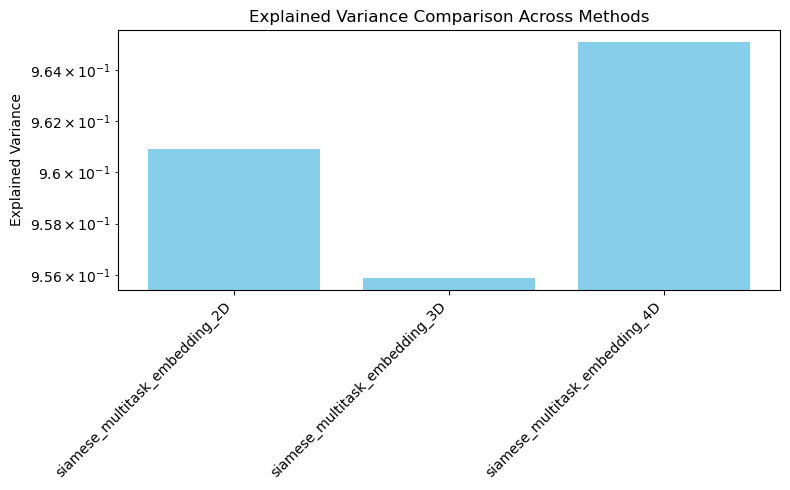

In [10]:
method_explained_variances = {}

for m_name, data_dict in results.items():
    all_preds = data_dict["all_preds"]  # shape [N_test, 17]
    all_true = data_dict["all_true"]    # shape [N_test, 17]

    # If it's already in the dictionary:
    if "explained_variance" in data_dict:
        ev = data_dict["explained_variance"]
    else:
        # Calculate it if not stored
        cov_matrix = np.cov(all_true, rowvar=False)
        total_variance = np.trace(cov_matrix)
        mse_global = np.mean((all_preds - all_true)**2)
        explained_variance = 1 - (mse_global / total_variance)

    method_explained_variances[m_name] = ev

# Plot a bar chart of explained variance for each method
plt.figure(figsize=(8, 5))
labels = list(method_explained_variances.keys())
ev_values = [method_explained_variances[m] for m in labels]
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.semilogy()
plt.title("Explained Variance Comparison Across Methods")
plt.tight_layout()
plt.show()
